<a href="https://colab.research.google.com/github/kyokux2/Laboratorio3token/blob/main/BPETokenization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch numpy matplotlib tqdm requests

In [2]:
import os
import math
import time
import random
import requests
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [4]:
url = "https://www.gutenberg.org/files/11/11-0.txt"
path = "input.txt"

if not os.path.exists(path):
    response = requests.get(url)
    response.raise_for_status()

    with open(path, "w", encoding="utf-8") as f:
        f.write(response.text)

with open(path, "r", encoding="utf-8") as f:
    text = f.read()

print("Longitud del texto:", len(text))
print(text[:1000])

Longitud del texto: 144696
*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The Mock Turtle’s Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice’s Evidence




CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”

So

In [5]:
text = text.lower()

start_marker = "*** start of the project gutenberg ebook"
end_marker = "*** end of the project gutenberg ebook"

start_idx = text.find(start_marker)
end_idx = text.find(end_marker)

if start_idx != -1:
    text = text[start_idx:]

if end_idx != -1:
    text = text[:end_idx]

print("Longitud después de limpieza:", len(text))
print(text[:1000])

Longitud después de limpieza: 144650
*** start of the project gutenberg ebook 11 ***

[illustration]




alice’s adventures in wonderland

by lewis carroll

the millennium fulcrum edition 3.0

contents

 chapter i.     down the rabbit-hole
 chapter ii.    the pool of tears
 chapter iii.   a caucus-race and a long tale
 chapter iv.    the rabbit sends in a little bill
 chapter v.     advice from a caterpillar
 chapter vi.    pig and pepper
 chapter vii.   a mad tea-party
 chapter viii.  the queen’s croquet-ground
 chapter ix.    the mock turtle’s story
 chapter x.     the lobster quadrille
 chapter xi.    who stole the tarts?
 chapter xii.   alice’s evidence




chapter i.
down the rabbit-hole


alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought alice
“without pictures or conversat

In [6]:
import re
from collections import Counter, defaultdict

def basic_tokenize(text):
    return re.findall(r"\w+|[^\w\s]", text, re.UNICODE)


def get_word_vocab(text):
    raw_tokens = basic_tokenize(text)
    vocab_counter = Counter()

    for token in raw_tokens:
        if token.isalnum():
            symbols = tuple(list(token) + ["</w>"])
        else:
            symbols = tuple([token])

        vocab_counter[symbols] += 1

    return vocab_counter


def get_pair_stats(vocab_counter):
    pairs = defaultdict(int)

    for symbols, freq in vocab_counter.items():
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i + 1])] += freq

    return pairs


def merge_pair(pair, vocab_counter):
    new_vocab = {}

    bigram = " ".join(pair)
    replacement = "".join(pair)

    for symbols, freq in vocab_counter.items():
        symbols_str = " ".join(symbols)
        new_symbols_str = symbols_str.replace(bigram, replacement)
        new_symbols = tuple(new_symbols_str.split(" "))
        new_vocab[new_symbols] = freq

    return Counter(new_vocab)


def train_bpe(text, num_merges=300):
    vocab_counter = get_word_vocab(text)
    merges = []

    for i in range(num_merges):
        pairs = get_pair_stats(vocab_counter)

        if not pairs:
            break

        best_pair = max(pairs, key=pairs.get)
        vocab_counter = merge_pair(best_pair, vocab_counter)
        merges.append(best_pair)

        if (i + 1) % 50 == 0:
            print(f"BPE merge {i + 1}/{num_merges}: {best_pair}")

    return merges


def apply_bpe_to_token(token, merges):
    if token.isalnum():
        symbols = list(token) + ["</w>"]
    else:
        return [token]

    for pair in merges:
        i = 0
        new_symbols = []

        while i < len(symbols):
            if i < len(symbols) - 1 and symbols[i] == pair[0] and symbols[i + 1] == pair[1]:
                new_symbols.append(symbols[i] + symbols[i + 1])
                i += 2
            else:
                new_symbols.append(symbols[i])
                i += 1

        symbols = new_symbols

    return symbols


def bpe_tokenize(text, merges):
    raw_tokens = basic_tokenize(text)
    output_tokens = []

    for token in raw_tokens:
        output_tokens.extend(apply_bpe_to_token(token, merges))

    return output_tokens


num_merges = 300

merges = train_bpe(text, num_merges=num_merges)
bpe_tokens = bpe_tokenize(text, merges)

vocab = sorted(list(set(bpe_tokens)))
vocab_size = len(vocab)

stoi = {token: i for i, token in enumerate(vocab)}
itos = {i: token for token, i in stoi.items()}

def encode(token_list):
    return [stoi[token] for token in token_list]

def decode(ids):
    decoded_tokens = [itos[i] for i in ids]

    text_decoded = "".join(decoded_tokens)
    text_decoded = text_decoded.replace("</w>", " ")

    text_decoded = re.sub(r"\s+([.,!?;:])", r"\1", text_decoded)
    text_decoded = re.sub(r"\s+", " ", text_decoded)

    return text_decoded.strip()


print("Número total de BPE tokens:", len(bpe_tokens))
print("Tamaño del vocabulario BPE:", vocab_size)
print("Primeros tokens BPE:")
print(bpe_tokens[:100])

BPE merge 50/300: ('k', '</w>')
BPE merge 100/300: ('n', 'e')
BPE merge 150/300: ('k', 'now</w>')
BPE merge 200/300: ('g', 's</w>')
BPE merge 250/300: ('e', 'ver</w>')
BPE merge 300/300: ('o', 'p')
Número total de BPE tokens: 64096
Tamaño del vocabulario BPE: 429
Primeros tokens BPE:
['*', '*', '*', 'st', 'ar', 't</w>', 'of</w>', 'the</w>', 'p', 'ro', 'j', 'ec', 't</w>', 'gu', 't', 'en', 'b', 'er', 'g</w>', 'e', 'b', 'oo', 'k</w>', '1', '1', '</w>', '*', '*', '*', '[', 'i', 'l', 'l', 'u', 'st', 'ra', 'ti', 'o', 'n</w>', ']', 'alice</w>', '’', 's</w>', 'ad', 'v', 'en', 't', 'u', 're', 's</w>', 'i', 'n</w>', 'w', 'on', 'd', 'er', 'l', 'and</w>', 'by</w>', 'le', 'w', 'is</w>', 'c', 'ar', 'ro', 'll</w>', 'the</w>', 'mi', 'l', 'l', 'en', 'n', 'i', 'u', 'm</w>', 'fu', 'l', 'c', 'ru', 'm</w>', 'e', 'd', 'it', 'i', 'o', 'n</w>', '3', '</w>', '.', '0', '</w>', 'c', 'on', 't', 'en', 'ts</w>', 'ch', 'a', 'p', 'ter</w>']


In [7]:
data = torch.tensor(encode(bpe_tokens), dtype=torch.long)

train_size = int(0.9 * len(data))
train_data = data[:train_size]
val_data = data[train_size:]

block_size = 64
batch_size = 64

def get_batch(split):
    source = train_data if split == "train" else val_data

    ix = torch.randint(len(source) - block_size - 1, (batch_size,))

    x = torch.stack([source[i:i+block_size] for i in ix])
    y = torch.stack([source[i+1:i+block_size+1] for i in ix])

    x = x.to(device)
    y = y.to(device)

    return x, y

x, y = get_batch("train")

print(x.shape)
print(y.shape)
print(decode(x[0].tolist()))
print("---- TARGET ----")
print(decode(y[0].tolist()))

torch.Size([64, 64])
torch.Size([64, 64])
herself “suppose it should be raving mad after all!i almost wish i ’d gone to see the hatter instead!”chapter vii.a mad tea -part
---- TARGET ----
self “suppose it should be raving mad after all!i almost wish i ’d gone to see the hatter instead!”chapter vii.a mad tea -party


In [8]:
@torch.no_grad()
def estimate_loss(model, eval_iters=50):
    results = {}

    model.eval()

    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):
            x, y = get_batch(split)
            logits, loss = model(x, y)
            losses[k] = loss.item()

        results[split] = losses.mean().item()

    model.train()
    return results

In [9]:
def train_model(model, model_name, max_iters=1000, eval_interval=200, learning_rate=3e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    history = {
        "model": [],
        "iter": [],
        "train_loss": [],
        "val_loss": [],
        "train_perplexity": [],
        "val_perplexity": []
    }

    model.train()

    for iteration in range(max_iters + 1):

        if iteration % eval_interval == 0:
            losses = estimate_loss(model)

            train_loss = losses["train"]
            val_loss = losses["val"]

            train_ppl = math.exp(train_loss)
            val_ppl = math.exp(val_loss)

            history["model"].append(model_name)
            history["iter"].append(iteration)
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_perplexity"].append(train_ppl)
            history["val_perplexity"].append(val_ppl)

            print(
                f"{model_name} | iter {iteration}: "
                f"train loss {train_loss:.4f}, val loss {val_loss:.4f}, "
                f"train ppl {train_ppl:.2f}, val ppl {val_ppl:.2f}"
            )

        x, y = get_batch("train")

        logits, loss = model(x, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

    return history

In [10]:
class SimpleRNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, idx, targets=None):
        x = self.embedding(idx)

        output, hidden = self.rnn(x)

        logits = self.fc(output)

        loss = None

        if targets is not None:
            batch_size, seq_len, vocab_size_local = logits.shape

            logits_flat = logits.view(batch_size * seq_len, vocab_size_local)
            targets_flat = targets.view(batch_size * seq_len)

            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=300, temperature=1.0):
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]

            logits, loss = self(idx_cond)

            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            idx_next = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, idx_next), dim=1)

        self.train()

        return idx

In [11]:
simple_rnn = SimpleRNNLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=1
).to(device)

print("Número de parámetros:", sum(p.numel() for p in simple_rnn.parameters()))

history_simple_rnn = train_model(
    model=simple_rnn,
    model_name="Simple RNN",
    max_iters=1000,
    eval_interval=200,
    learning_rate=3e-4
)

Número de parámetros: 263981
Simple RNN | iter 0: train loss 6.0822, val loss 6.0850, train ppl 437.98, val ppl 439.23
Simple RNN | iter 200: train loss 3.8875, val loss 4.0414, train ppl 48.79, val ppl 56.90
Simple RNN | iter 400: train loss 3.2765, val loss 3.5560, train ppl 26.48, val ppl 35.02
Simple RNN | iter 600: train loss 2.9310, val loss 3.3537, train ppl 18.75, val ppl 28.61
Simple RNN | iter 800: train loss 2.7027, val loss 3.2422, train ppl 14.92, val ppl 25.59
Simple RNN | iter 1000: train loss 2.5164, val loss 3.1650, train ppl 12.38, val ppl 23.69


In [12]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = simple_rnn.generate(
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text_simple_rnn = decode(generated_ids[0].tolist())

print(generated_text_simple_rnn)

!”alice anxiously sean very voice;“and forttty!and o quite round that the gryphon.“i must confusn ’t take with the white?”“i never heard that is the mper swere?”she said prather,and said,was comdended lare;“if you can ’t ree curiought.“i ’m afraid i don ’t sual!”a crabbit,in the soon ah.for fallent at the ssknegraill the same ojoger from the hatter.“but just much,”alice said sed his conversations to drin acontell,and went on and the hatter went our of the lobster of the bottle uoff stect of horgoutipation,and so she could not the ute or two,they perro;and if it came uth explat,”the dodo,the mock turtle cket up she was gone ialice.“who was at its on tround close to do.”“she ’s no sort of putes,you know i dish?”the chook up by the roshs were now and band made a way she was an for it,and began to see.the mouse,that she had to under fell that,”said the gryion,and she sounded long close thrswatched the words was —it beg,”“alice usutting on cat the soog quill ifted the facried his poor tunof

In [13]:
generated_samples = {}

generated_samples["Simple RNN"] = generated_text_simple_rnn

print(generated_samples["Simple RNN"])

!”alice anxiously sean very voice;“and forttty!and o quite round that the gryphon.“i must confusn ’t take with the white?”“i never heard that is the mper swere?”she said prather,and said,was comdended lare;“if you can ’t ree curiought.“i ’m afraid i don ’t sual!”a crabbit,in the soon ah.for fallent at the ssknegraill the same ojoger from the hatter.“but just much,”alice said sed his conversations to drin acontell,and went on and the hatter went our of the lobster of the bottle uoff stect of horgoutipation,and so she could not the ute or two,they perro;and if it came uth explat,”the dodo,the mock turtle cket up she was gone ialice.“who was at its on tround close to do.”“she ’s no sort of putes,you know i dish?”the chook up by the roshs were now and band made a way she was an for it,and began to see.the mouse,that she had to under fell that,”said the gryion,and she sounded long close thrswatched the words was —it beg,”“alice usutting on cat the soog quill ifted the facried his poor tunof

In [14]:
class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, num_layers=1, bidirectional=False):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )

        direction_factor = 2 if bidirectional else 1

        self.fc = nn.Linear(hidden_dim * direction_factor, vocab_size)

    def forward(self, idx, targets=None):
        x = self.embedding(idx)

        output, hidden = self.lstm(x)

        logits = self.fc(output)

        loss = None

        if targets is not None:
            batch_size, seq_len, vocab_size_local = logits.shape

            logits_flat = logits.view(batch_size * seq_len, vocab_size_local)
            targets_flat = targets.view(batch_size * seq_len)

            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=300, temperature=1.0):
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]

            logits, loss = self(idx_cond)

            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            idx_next = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, idx_next), dim=1)

        self.train()

        return idx

In [15]:
lstm_1_layer = LSTMLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=1,
    bidirectional=False
).to(device)

print("Número de parámetros:", sum(p.numel() for p in lstm_1_layer.parameters()))

history_lstm_1_layer = train_model(
    model=lstm_1_layer,
    model_name="LSTM 1 layer",
    max_iters=1000,
    eval_interval=200,
    learning_rate=3e-4
)

Número de parámetros: 560429
LSTM 1 layer | iter 0: train loss 6.0611, val loss 6.0616, train ppl 428.84, val ppl 429.06
LSTM 1 layer | iter 200: train loss 4.2969, val loss 4.3720, train ppl 73.47, val ppl 79.20
LSTM 1 layer | iter 400: train loss 3.5901, val loss 3.7767, train ppl 36.24, val ppl 43.67
LSTM 1 layer | iter 600: train loss 3.2309, val loss 3.4793, train ppl 25.30, val ppl 32.44
LSTM 1 layer | iter 800: train loss 2.9859, val loss 3.3262, train ppl 19.80, val ppl 27.83
LSTM 1 layer | iter 1000: train loss 2.7964, val loss 3.2198, train ppl 16.39, val ppl 25.02


In [16]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = lstm_1_layer.generate(
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text_lstm_1_layer = decode(generated_ids[0].tolist())

print(generated_text_lstm_1_layer)

!chah,”said alice.“it ’s arm ful.”but a slatting of just,and the cconfulant of the titof cour fear off,alice.“not teet,”thought she more.“i don ’t be in a crry watters,”said the caterllarly with a kiny,it had asked then:to say,but she came to make out of she was,and she went on a mdiminute danger,“why,you we ’s very!”two there when a low where when she was terned;but then repliced it down eyes all a little pased;but she went on,“it ’s were pered beapps in ha mallons sarknow,and somethat day,and en seen.you like a talk out of it,and the march hare -butter,on quite a garden,for the prosing on the cat the table,“i don ’t go up from one that ’s were,now and that she ded an _very_?”“by i ’m afraid when ’s?”“can ’t day,”said the hatter.“i think you ’d tainning it is,”said the sormouse,“i can,what all just were dere happenged,and these,”said alice,“it ’s round,and one ough that late!”said the mouse,and the stardly ucark took )one the hear,and alice went on.“i wonder the poor,when you know.”“i

In [17]:
generated_samples["LSTM 1 layer"] = generated_text_lstm_1_layer

print(generated_samples["LSTM 1 layer"])

!chah,”said alice.“it ’s arm ful.”but a slatting of just,and the cconfulant of the titof cour fear off,alice.“not teet,”thought she more.“i don ’t be in a crry watters,”said the caterllarly with a kiny,it had asked then:to say,but she came to make out of she was,and she went on a mdiminute danger,“why,you we ’s very!”two there when a low where when she was terned;but then repliced it down eyes all a little pased;but she went on,“it ’s were pered beapps in ha mallons sarknow,and somethat day,and en seen.you like a talk out of it,and the march hare -butter,on quite a garden,for the prosing on the cat the table,“i don ’t go up from one that ’s were,now and that she ded an _very_?”“by i ’m afraid when ’s?”“can ’t day,”said the hatter.“i think you ’d tainning it is,”said the sormouse,“i can,what all just were dere happenged,and these,”said alice,“it ’s round,and one ough that late!”said the mouse,and the stardly ucark took )one the hear,and alice went on.“i wonder the poor,when you know.”“i

In [18]:
lstm_multi_layer = LSTMLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    bidirectional=False
).to(device)

print("Número de parámetros:", sum(p.numel() for p in lstm_multi_layer.parameters()))

history_lstm_multi_layer = train_model(
    model=lstm_multi_layer,
    model_name="LSTM multi layer",
    max_iters=1000,
    eval_interval=200,
    learning_rate=3e-4
)

Número de parámetros: 1086765
LSTM multi layer | iter 0: train loss 6.0626, val loss 6.0638, train ppl 429.51, val ppl 430.03
LSTM multi layer | iter 200: train loss 4.6796, val loss 4.7162, train ppl 107.73, val ppl 111.75
LSTM multi layer | iter 400: train loss 3.8782, val loss 3.9872, train ppl 48.34, val ppl 53.90
LSTM multi layer | iter 600: train loss 3.4374, val loss 3.6359, train ppl 31.11, val ppl 37.93
LSTM multi layer | iter 800: train loss 3.1302, val loss 3.4611, train ppl 22.88, val ppl 31.85
LSTM multi layer | iter 1000: train loss 2.8787, val loss 3.3363, train ppl 17.79, val ppl 28.12


In [19]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = lstm_multi_layer.generate(
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text_lstm_multi_layer = decode(generated_ids[0].tolist())

print(generated_text_lstm_multi_layer)

!”“the larging at have inimintes,when you parked,what no,”said the poop.alice did it was telits feow of spight day,,with ge way to way,”said the chance,and “it wat,and ’s no enid ”the duchess souse,that out _not_at his head.talking hopliin;“and this time they came r of of worsps:“you ’ll actial,”said the gryphon.“what if healtell they gdeing out.”“he ’re sernering at the pupmting,”said alice,“must spe now?”said alice,versiles with now.”“i don ’t think,”said the piyf,“there beolded there were?”alice ping once derenly.“i don ’t be grows me dory,”the queen cnrining houts.“now.”“tweldy:‘be you in the hound!”the flattable.“oh!if that is the dear of bet of here it,”said the mock turtle;“but began,in go on yet,”said alice.“if i we that pood of the air,as make by of any cdy,”licreat alice teyes,but she hatter ked.”“well,’ll be —”she went on,but at had all and a moment the saange.“i wut like a shanging about a table!of the pary let!”said the gryphon:“i made quat all,”said at the reatercular,had

In [20]:
generated_samples["LSTM multi layer"] = generated_text_lstm_multi_layer

print(generated_samples["LSTM multi layer"])

!”“the larging at have inimintes,when you parked,what no,”said the poop.alice did it was telits feow of spight day,,with ge way to way,”said the chance,and “it wat,and ’s no enid ”the duchess souse,that out _not_at his head.talking hopliin;“and this time they came r of of worsps:“you ’ll actial,”said the gryphon.“what if healtell they gdeing out.”“he ’re sernering at the pupmting,”said alice,“must spe now?”said alice,versiles with now.”“i don ’t think,”said the piyf,“there beolded there were?”alice ping once derenly.“i don ’t be grows me dory,”the queen cnrining houts.“now.”“tweldy:‘be you in the hound!”the flattable.“oh!if that is the dear of bet of here it,”said the mock turtle;“but began,in go on yet,”said alice.“if i we that pood of the air,as make by of any cdy,”licreat alice teyes,but she hatter ked.”“well,’ll be —”she went on,but at had all and a moment the saange.“i wut like a shanging about a table!of the pary let!”said the gryphon:“i made quat all,”said at the reatercular,had

In [21]:
all_histories = []

all_histories.extend([
    history_simple_rnn,
    history_lstm_1_layer,
    history_lstm_multi_layer
])

print("Historiales guardados:", len(all_histories))

Historiales guardados: 3


In [22]:
bilstm = LSTMLanguageModel(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=1,
    bidirectional=True
).to(device)

print("Número de parámetros:", sum(p.numel() for p in bilstm.parameters()))

history_bilstm = train_model(
    model=bilstm,
    model_name="Bidirectional LSTM",
    max_iters=1000,
    eval_interval=200,
    learning_rate=3e-4
)

Número de parámetros: 1065517
Bidirectional LSTM | iter 0: train loss 6.0620, val loss 6.0627, train ppl 429.22, val ppl 429.54
Bidirectional LSTM | iter 200: train loss 1.4835, val loss 1.6514, train ppl 4.41, val ppl 5.21
Bidirectional LSTM | iter 400: train loss 0.3592, val loss 0.5003, train ppl 1.43, val ppl 1.65
Bidirectional LSTM | iter 600: train loss 0.1546, val loss 0.2653, train ppl 1.17, val ppl 1.30
Bidirectional LSTM | iter 800: train loss 0.1020, val loss 0.1947, train ppl 1.11, val ppl 1.21
Bidirectional LSTM | iter 1000: train loss 0.0814, val loss 0.1652, train ppl 1.08, val ppl 1.18


In [23]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = bilstm.generate(
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text_bilstm = decode(generated_ids[0].tolist())

print(generated_text_bilstm)

!s and that _his_sing _best_her to rues;a _little_down in this sea.but (which,_sheto _me_tly rean the hatter,and they _said_dly _best_ortalaled;and herforelwords this back in up quemight.“come o idonce and some!”“i ’s you tting hold treage ge irter?”said alice:se had beg.“you _must_k they at _have__curtseying_have he said would _not_thing loostin,”“you talrets of the if “of of figunaers bok them,liglip about tening of _mine_i ’rul phtea _very_ber ad,and was by a said!she said to set,as a speaeak nofor tury:this irried alice,(uate coor ticureplar,and went the mock turtle ing down a larer it,”said the hatter falve said.“_youwilliam_to ounow the voice pritly,i can.“who ken!”ra,”she the hpspeen “very and down ormemed,“wheecally,and her,and that she was back g ta cake begate jent own own _very_de ers,“but i have at words -sa,”said alice graded,”said the the oodecturtle _must_this.“his a bremoin the meat bow into him up said ryelt arning reanot?to have higes ts come erwould _two__two_evn.“th

In [24]:
generated_samples["Bidirectional LSTM"] = generated_text_bilstm

print(generated_samples["Bidirectional LSTM"])

!s and that _his_sing _best_her to rues;a _little_down in this sea.but (which,_sheto _me_tly rean the hatter,and they _said_dly _best_ortalaled;and herforelwords this back in up quemight.“come o idonce and some!”“i ’s you tting hold treage ge irter?”said alice:se had beg.“you _must_k they at _have__curtseying_have he said would _not_thing loostin,”“you talrets of the if “of of figunaers bok them,liglip about tening of _mine_i ’rul phtea _very_ber ad,and was by a said!she said to set,as a speaeak nofor tury:this irried alice,(uate coor ticureplar,and went the mock turtle ing down a larer it,”said the hatter falve said.“_youwilliam_to ounow the voice pritly,i can.“who ken!”ra,”she the hpspeen “very and down ormemed,“wheecally,and her,and that she was back g ta cake begate jent own own _very_de ers,“but i have at words -sa,”said alice graded,”said the the oodecturtle _must_this.“his a bremoin the meat bow into him up said ryelt arning reanot?to have higes ts come erwould _two__two_evn.“th

In [25]:
all_histories = []

all_histories.extend([
    history_simple_rnn,
    history_lstm_1_layer,
    history_lstm_multi_layer,
    history_bilstm
])

print("Historiales guardados:", len(all_histories))

Historiales guardados: 4


In [26]:
import pandas as pd

rows = []

for history in all_histories:
    final_index = -1

    rows.append({
        "model": history["model"][final_index],
        "final_iter": history["iter"][final_index],
        "train_loss": history["train_loss"][final_index],
        "val_loss": history["val_loss"][final_index],
        "train_perplexity": history["train_perplexity"][final_index],
        "val_perplexity": history["val_perplexity"][final_index],
    })

results_df = pd.DataFrame(rows)
results_df

,model,final_iter,train_loss,val_loss,train_perplexity,val_perplexity
0,Simple RNN,1000,2.516438,3.164955,12.384411,23.687676
1,LSTM 1 layer,1000,2.796372,3.219815,16.385100,25.023491
2,LSTM multi layer,1000,2.878738,3.336345,17.791800,28.116180
3,Bidirectional LSTM,1000,0.081438,0.165161,1.084846,1.179584


In [27]:
class Head(nn.Module):
    def __init__(self, head_size, n_embd, block_size, dropout=0.2):
        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        self.register_buffer(
            "tril",
            torch.tril(torch.ones(block_size, block_size))
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, seq_len, channels = x.shape

        k = self.key(x)
        q = self.query(x)

        weights = q @ k.transpose(-2, -1) * channels ** -0.5
        weights = weights.masked_fill(
            self.tril[:seq_len, :seq_len] == 0,
            float("-inf")
        )

        weights = F.softmax(weights, dim=-1)
        weights = self.dropout(weights)

        v = self.value(x)
        output = weights @ v

        return output


class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size, n_embd, block_size, dropout=0.2):
        super().__init__()

        self.heads = nn.ModuleList([
            Head(head_size, n_embd, block_size, dropout)
            for _ in range(num_heads)
        ])

        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        output = torch.cat([head(x) for head in self.heads], dim=-1)
        output = self.proj(output)
        output = self.dropout(output)

        return output


class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout=0.2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout=0.2):
        super().__init__()

        head_size = n_embd // n_head

        self.self_attention = MultiHeadAttention(
            num_heads=n_head,
            head_size=head_size,
            n_embd=n_embd,
            block_size=block_size,
            dropout=dropout
        )

        self.feed_forward = FeedForward(n_embd, dropout)

        self.layer_norm_1 = nn.LayerNorm(n_embd)
        self.layer_norm_2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.self_attention(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))

        return x

In [28]:
class GPTLanguageModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        block_size,
        n_embd=128,
        n_head=4,
        n_layer=4,
        dropout=0.2
    ):
        super().__init__()

        self.block_size = block_size

        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        self.blocks = nn.Sequential(*[
            Block(n_embd, n_head, block_size, dropout)
            for _ in range(n_layer)
        ])

        self.layer_norm_final = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        batch_size, seq_len = idx.shape

        token_embeddings = self.token_embedding_table(idx)

        positions = torch.arange(seq_len, device=idx.device)
        position_embeddings = self.position_embedding_table(positions)

        x = token_embeddings + position_embeddings

        x = self.blocks(x)
        x = self.layer_norm_final(x)

        logits = self.lm_head(x)

        loss = None

        if targets is not None:
            batch_size, seq_len, vocab_size_local = logits.shape

            logits_flat = logits.reshape(batch_size * seq_len, vocab_size_local)
            targets_flat = targets.reshape(batch_size * seq_len)

            loss = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=300, temperature=1.0):
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]

            logits, loss = self(idx_cond)

            logits = logits[:, -1, :] / temperature

            probs = F.softmax(logits, dim=-1)

            idx_next = torch.multinomial(probs, num_samples=1)

            idx = torch.cat((idx, idx_next), dim=1)

        self.train()

        return idx

In [29]:
gpt_model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=128,
    n_head=4,
    n_layer=4,
    dropout=0.2
).to(device)

print("Número de parámetros:", sum(p.numel() for p in gpt_model.parameters()))

history_gpt = train_model(
    model=gpt_model,
    model_name="GPT from scratch",
    max_iters=1000,
    eval_interval=200,
    learning_rate=3e-4
)

Número de parámetros: 910253
GPT from scratch | iter 0: train loss 6.2509, val loss 6.2548, train ppl 518.49, val ppl 520.51
GPT from scratch | iter 200: train loss 3.8743, val loss 3.9910, train ppl 48.15, val ppl 54.11
GPT from scratch | iter 400: train loss 3.4673, val loss 3.6513, train ppl 32.05, val ppl 38.53
GPT from scratch | iter 600: train loss 3.2714, val loss 3.5351, train ppl 26.35, val ppl 34.30
GPT from scratch | iter 800: train loss 3.1034, val loss 3.4209, train ppl 22.27, val ppl 30.60
GPT from scratch | iter 1000: train loss 2.9120, val loss 3.3108, train ppl 18.39, val ppl 27.41


In [30]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated_ids = gpt_model.generate(
    context,
    max_new_tokens=500,
    temperature=0.8
)

generated_text_gpt = decode(generated_ids[0].tolist())

print(generated_text_gpt)

!”“i ’ve take like work.”alice mouse anon.“you fy,”said alice,“were rememno member,”said the mock turtle:“i ’m a any talked,”consionies.“i can ’t time,”said alice.“that ’s a little bin maged,”said the duchess,“you ’ll talking,”said alice.“no,”said alice.“i cat here out _that_rain.quin,”she did not.“well,i ’ve begine to get me,”said the did not wong,“i ’ll go,”said the be in a lardid there glive.“you well me what i ’m,the when i ’ll scould be the end,”“i ’m ’ll be five grown out,,”said alice interpilong,and,she thought alice,and looked at an in a waity.“come here they well to say what you ’re not to beginning!”said the duchess:“but i _red_mouse!”said alice,“what!”said the mock turtle.“i must know,you might be see a knone,”said the ced the king.“i ’m not an a _very_promight,”said the hatter.“when,”the mock turtle said alice an they ’s of them,so alice,and pully,il would bures no speak.“you ’row!”“no,”said alice,“he ’ll be the queen ’t.”“they well,so gre,”said the duchess:“that ’s am to b

In [31]:
generated_samples["GPT from scratch"] = generated_text_gpt

print(generated_samples["GPT from scratch"])

!”“i ’ve take like work.”alice mouse anon.“you fy,”said alice,“were rememno member,”said the mock turtle:“i ’m a any talked,”consionies.“i can ’t time,”said alice.“that ’s a little bin maged,”said the duchess,“you ’ll talking,”said alice.“no,”said alice.“i cat here out _that_rain.quin,”she did not.“well,i ’ve begine to get me,”said the did not wong,“i ’ll go,”said the be in a lardid there glive.“you well me what i ’m,the when i ’ll scould be the end,”“i ’m ’ll be five grown out,,”said alice interpilong,and,she thought alice,and looked at an in a waity.“come here they well to say what you ’re not to beginning!”said the duchess:“but i _red_mouse!”said alice,“what!”said the mock turtle.“i must know,you might be see a knone,”said the ced the king.“i ’m not an a _very_promight,”said the hatter.“when,”the mock turtle said alice an they ’s of them,so alice,and pully,il would bures no speak.“you ’row!”“no,”said alice,“he ’ll be the queen ’t.”“they well,so gre,”said the duchess:“that ’s am to b

In [32]:
all_histories = []

all_histories.extend([
    history_simple_rnn,
    history_lstm_1_layer,
    history_lstm_multi_layer,
    history_bilstm,
    history_gpt
])

rows = []

for history in all_histories:
    final_index = -1

    rows.append({
        "model": history["model"][final_index],
        "final_iter": history["iter"][final_index],
        "train_loss": history["train_loss"][final_index],
        "val_loss": history["val_loss"][final_index],
        "train_perplexity": history["train_perplexity"][final_index],
        "val_perplexity": history["val_perplexity"][final_index],
    })

results_df = pd.DataFrame(rows)
results_df

,model,final_iter,train_loss,val_loss,train_perplexity,val_perplexity
0,Simple RNN,1000,2.516438,3.164955,12.384411,23.687676
1,LSTM 1 layer,1000,2.796372,3.219815,16.385100,25.023491
2,LSTM multi layer,1000,2.878738,3.336345,17.791800,28.116180
3,Bidirectional LSTM,1000,0.081438,0.165161,1.084846,1.179584
4,GPT from scratch,1000,2.912025,3.310814,18.394013,27.407430


In [33]:
results_df.to_csv("bpe_tokenization_results.csv", index=False)

print("Resultados guardados en bpe_tokenization_results.csv")

Resultados guardados en bpe_tokenization_results.csv


In [34]:
for model_name, sample_text in generated_samples.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(sample_text[:1000])
    print()

Simple RNN
!”alice anxiously sean very voice;“and forttty!and o quite round that the gryphon.“i must confusn ’t take with the white?”“i never heard that is the mper swere?”she said prather,and said,was comdended lare;“if you can ’t ree curiought.“i ’m afraid i don ’t sual!”a crabbit,in the soon ah.for fallent at the ssknegraill the same ojoger from the hatter.“but just much,”alice said sed his conversations to drin acontell,and went on and the hatter went our of the lobster of the bottle uoff stect of horgoutipation,and so she could not the ute or two,they perro;and if it came uth explat,”the dodo,the mock turtle cket up she was gone ialice.“who was at its on tround close to do.”“she ’s no sort of putes,you know i dish?”the chook up by the roshs were now and band made a way she was an for it,and began to see.the mouse,that she had to under fell that,”said the gryion,and she sounded long close thrswatched the words was —it beg,”“alice usutting on cat the soog quill ifted the facried his

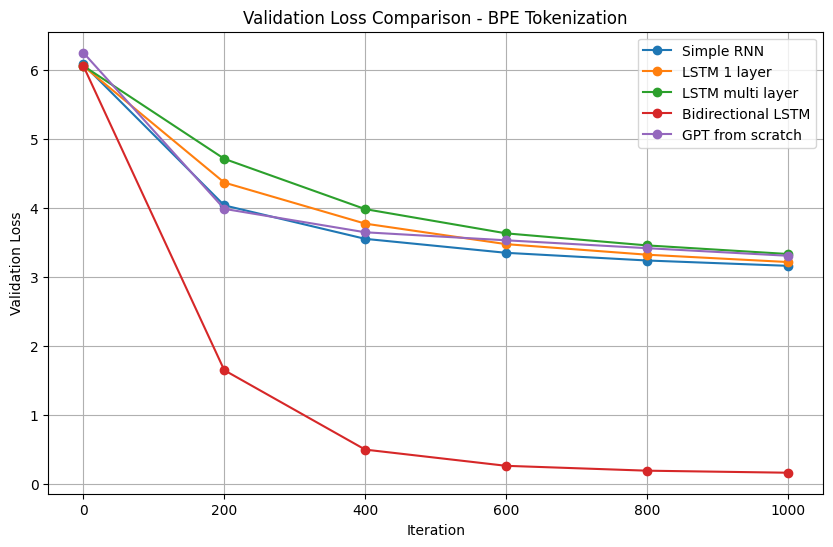

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for history in all_histories:
    plt.plot(
        history["iter"],
        history["val_loss"],
        marker="o",
        label=history["model"][-1]
    )

plt.xlabel("Iteration")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison - BPE Tokenization")
plt.legend()
plt.grid(True)
plt.show()